### AlexNet

#### 一、网络架构
- 底层（第1-2层卷积）：第一层神经元主要学习像素级的线条
- 中层（第3-4层卷积）：负责将线条拼接成纹理和局部形状
- 高层（第5卷积层以及全连接）：神经元可以识别抽象概念

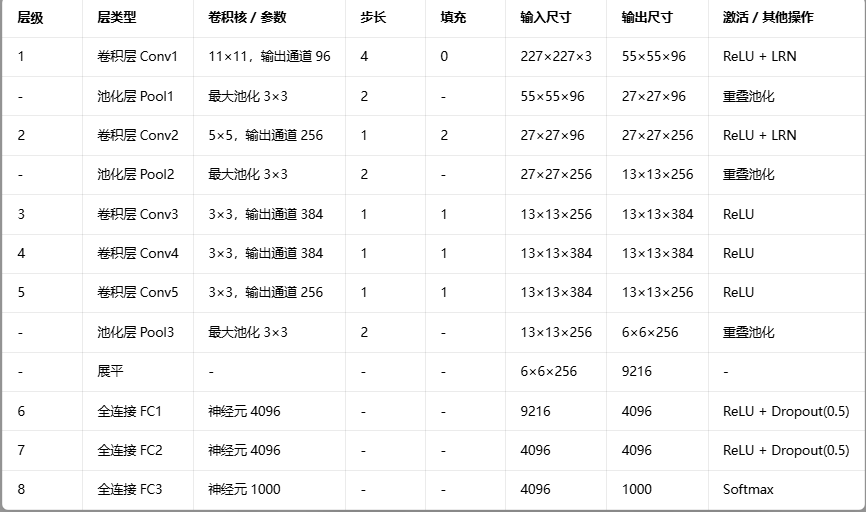

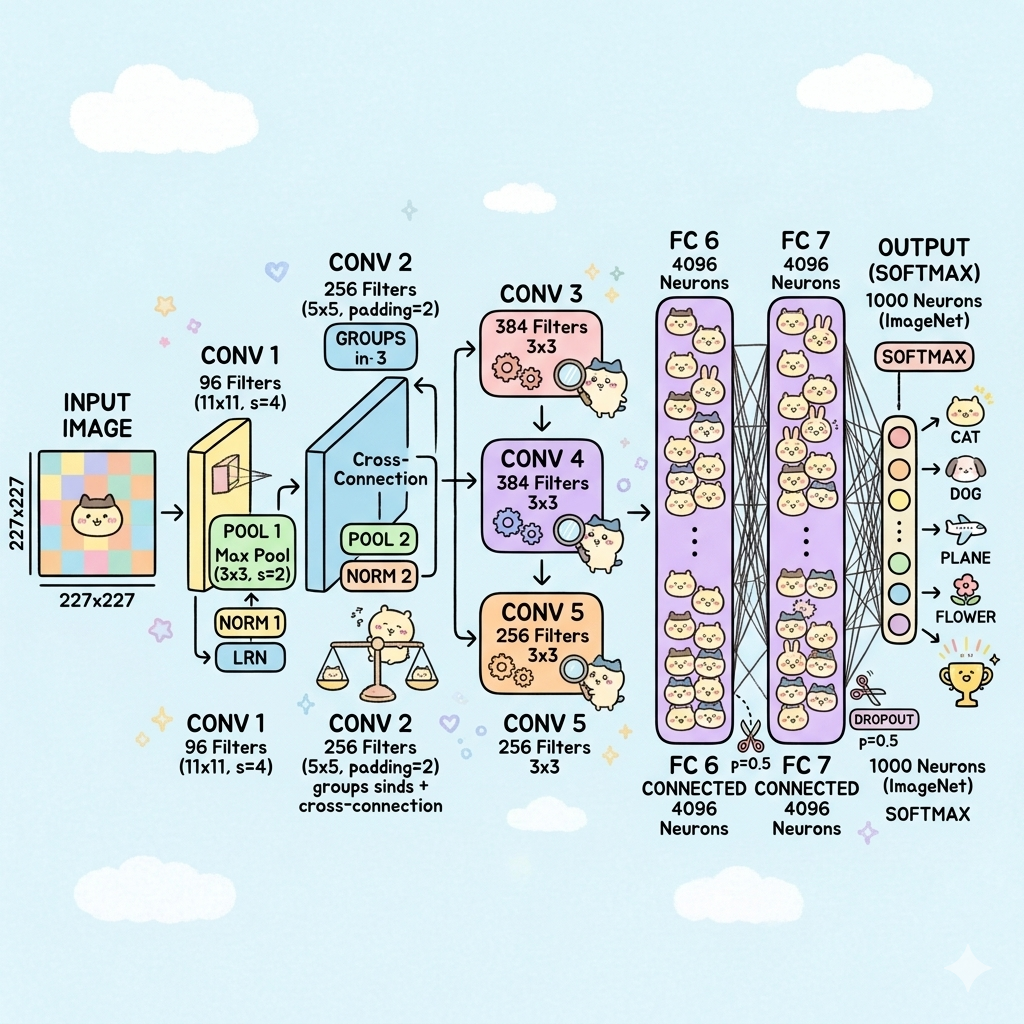

#### 二、三大核心
- ReLu激活：解决梯度消失
- 丢弃法：训练时随机让部分神经元熄火
- GPU并行：两块显卡并行计算

In [1]:
import torch 
from torch import nn
from torchsummary import summary
import torch.nn.functional as F 

In [6]:
class AlexNet(nn.Module):
  def __init__(self):
    super(AlexNet, self).__init__()
    self.ReLu = nn.ReLU()
    self.c1 = nn.Conv2d(in_channels = 1, out_channels = 96, kernel_size =11,stride =4)
    self.s2 = nn.MaxPool2d(kernel_size = 3, stride = 2)
    self.c3 = nn.Conv2d(in_channels = 96, out_channels =  256, kernel_size =5, stride=1, padding = 2)
    self.s4 = nn.MaxPool2d(kernel_size = 3, stride = 2)
    self.c5 = nn.Conv2d(in_channels = 256, out_channels = 384, kernel_size = 3, stride = 1, padding = 1)
    self.c6 = nn.Conv2d(in_channels = 384, out_channels = 384, kernel_size = 3, stride = 1, padding = 1)
    self.c7 = nn.Conv2d(in_channels = 384, out_channels = 256, kernel_size = 3, stride = 1, padding = 1)
    self.s8 = nn.MaxPool2d(kernel_size = 3, stride = 2)
    self.flatten = nn.Flatten()
    self.f1 = nn.Linear(6*6*256, 4096)
    self.f2 = nn.Linear(4096, 4096)
    self.f3 = nn.Linear(4096, 10)
  
  def forward(self,x):
    x = self.ReLu(self.c1(x))
    x = self.s2(x)
    x = self.ReLu(self.c3(x))
    x = self.s4(x)
    x = self.ReLu(self.c5(x))
    x = self.ReLu(self.c6(x))
    x = self.ReLu(self.c7(x))
    x = self.s8(x)

    x = self.flatten(x)
    x = self.ReLu(self.f1(x))
    x = F.dropout(x,0.5) 
    x = self.ReLu(self.f2(x))
    x = F.dropout(x,0.5)
    x = self.f3(x)
    return x


In [7]:
if __name__ == '__main__':
   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
   model = AlexNet().to(device)
   print(summary(model,(1,227,227)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          11,712
              ReLU-2           [-1, 96, 55, 55]               0
         MaxPool2d-3           [-1, 96, 27, 27]               0
            Conv2d-4          [-1, 256, 27, 27]         614,656
              ReLU-5          [-1, 256, 27, 27]               0
         MaxPool2d-6          [-1, 256, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         885,120
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 384, 13, 13]       1,327,488
             ReLU-10          [-1, 384, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         884,992
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
          Flatten-14                 [-